In [2]:
# 3.2.1. Kroki

In [3]:
# 1

In [4]:
import pandas as pd

plik = 'PRSA_Data_Wanshouxigong_20130301-20170228.csv'

dane = pd.read_csv(plik)

dane = dane.drop(columns=['No', 'wd', 'station'])

print(dane.head())
print(dane.info())

   year  month  day  hour  PM2.5  PM10  SO2   NO2     CO    O3  TEMP    PRES  \
0  2013      3    1     0    9.0   9.0  6.0  17.0  200.0  62.0   0.3  1021.9   
1  2013      3    1     1   11.0  11.0  7.0  14.0  200.0  66.0  -0.1  1022.4   
2  2013      3    1     2    8.0   8.0  NaN  16.0  200.0  59.0  -0.6  1022.6   
3  2013      3    1     3    8.0   8.0  3.0  16.0    NaN   NaN  -0.7  1023.5   
4  2013      3    1     4    8.0   8.0  3.0   NaN  300.0  36.0  -0.9  1024.1   

   DEWP  RAIN  WSPM  
0 -19.0   0.0   2.0  
1 -19.3   0.0   4.4  
2 -19.7   0.0   4.7  
3 -20.9   0.0   2.6  
4 -21.7   0.0   2.5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    35064 non-null  int64  
 1   month   35064 non-null  int64  
 2   day     35064 non-null  int64  
 3   hour    35064 non-null  int64  
 4   PM2.5   34368 non-null  float64
 5   PM10    34580 

In [5]:
#2

In [6]:
dane['Date'] = pd.to_datetime(dane[['year', 'month', 'day', 'hour']])

dane = dane.set_index('Date')

dane = dane.drop(columns=['year', 'month', 'day', 'hour'])

print(dane.head())
print(dane.info())

                     PM2.5  PM10  SO2   NO2     CO    O3  TEMP    PRES  DEWP  \
Date                                                                           
2013-03-01 00:00:00    9.0   9.0  6.0  17.0  200.0  62.0   0.3  1021.9 -19.0   
2013-03-01 01:00:00   11.0  11.0  7.0  14.0  200.0  66.0  -0.1  1022.4 -19.3   
2013-03-01 02:00:00    8.0   8.0  NaN  16.0  200.0  59.0  -0.6  1022.6 -19.7   
2013-03-01 03:00:00    8.0   8.0  3.0  16.0    NaN   NaN  -0.7  1023.5 -20.9   
2013-03-01 04:00:00    8.0   8.0  3.0   NaN  300.0  36.0  -0.9  1024.1 -21.7   

                     RAIN  WSPM  
Date                             
2013-03-01 00:00:00   0.0   2.0  
2013-03-01 01:00:00   0.0   4.4  
2013-03-01 02:00:00   0.0   4.7  
2013-03-01 03:00:00   0.0   2.6  
2013-03-01 04:00:00   0.0   2.5  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  -------

In [7]:
#3

Statystyki:
              PM2.5          PM10           SO2          NO2            CO  \
count  34368.000000  34580.000000  34395.000000  34310.00000  33767.000000   
mean      85.024136    112.223459     17.148603     55.52956   1370.395031   
std       85.975981     97.593210     23.940834     35.80805   1223.139114   
min        3.000000      2.000000      0.285600      2.00000    100.000000   
25%       23.000000     39.000000      3.000000     28.00000    600.000000   
50%       60.000000     91.000000      8.000000     49.00000   1000.000000   
75%      116.000000    154.000000     21.000000     77.00000   1700.000000   
max      999.000000    961.000000    411.000000    251.00000   9800.000000   

                 O3          TEMP          PRES          DEWP          RAIN  \
count  33986.000000  35045.000000  35045.000000  35045.000000  35045.000000   
mean      56.229904     13.784477   1011.511804      2.707442      0.064320   
std       57.082710     11.385156     10.570928 

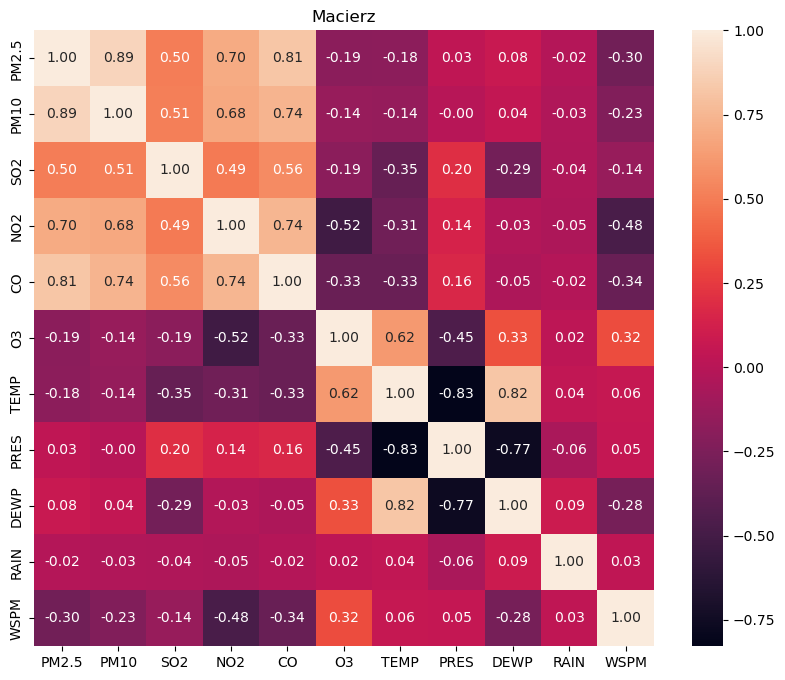

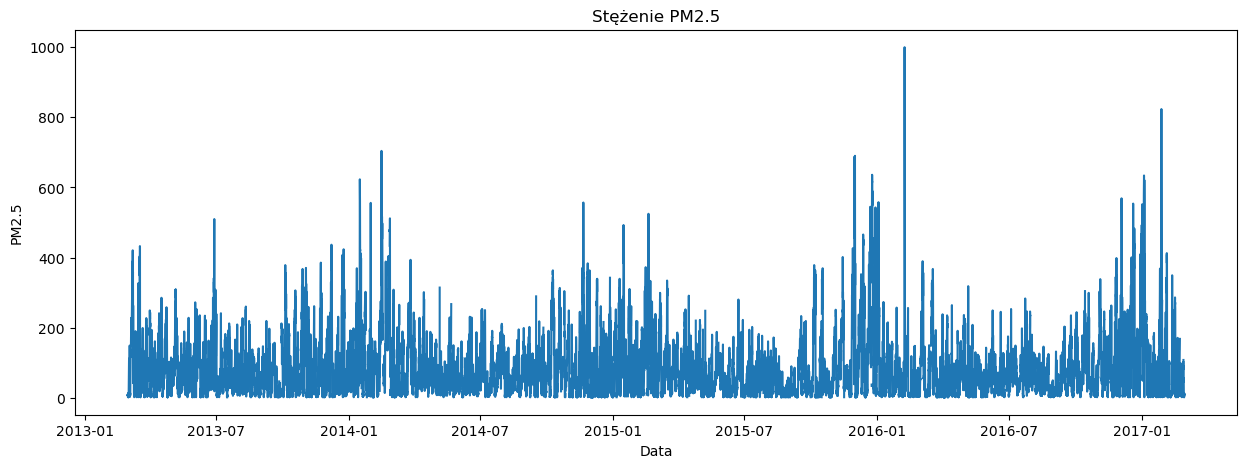

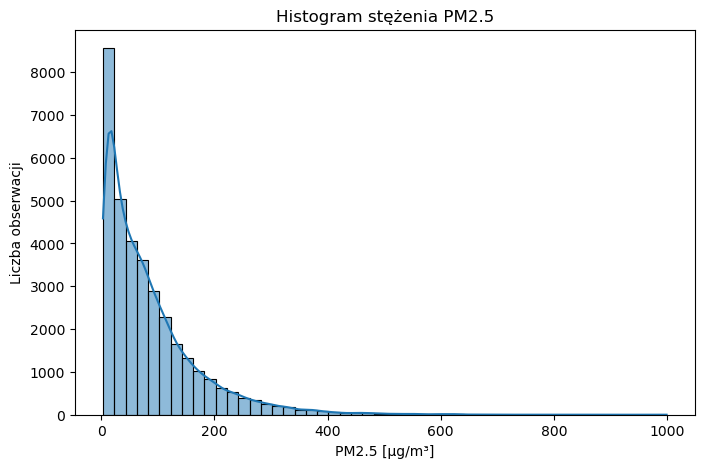

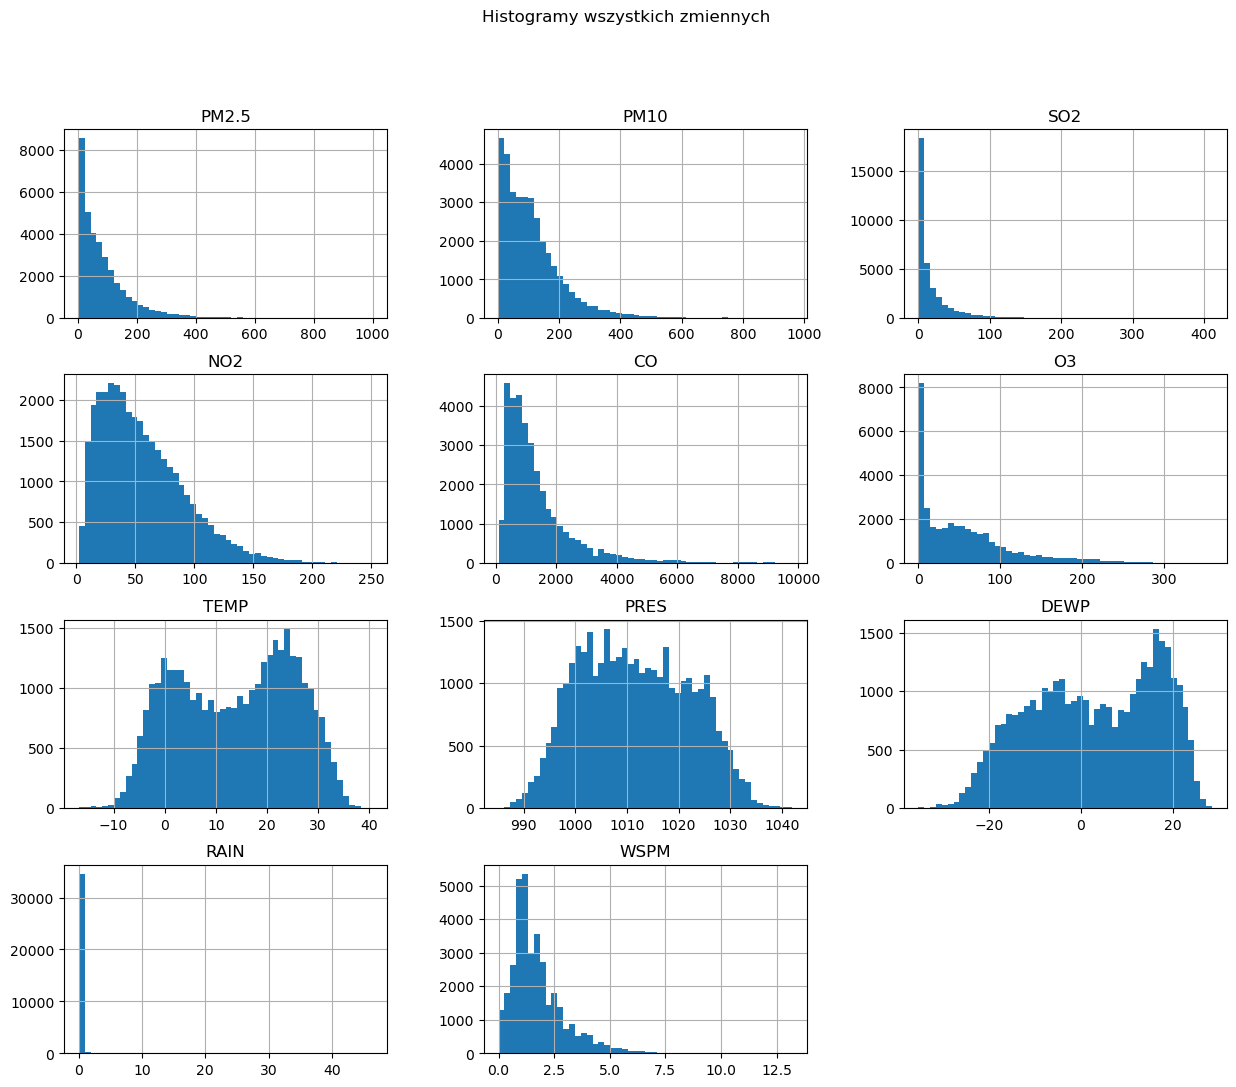

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Statystyki:")
print(dane.describe())

print("\nParametry rozkładów:")
print(f"Skewness (skośność) PM2.5: {dane['PM2.5'].skew():.2f}")
print(f"Kurtosis (kurtoza) PM2.5: {dane['PM2.5'].kurtosis():.2f}")

# Macierz korelacji
corr_matrix = dane.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Macierz")
plt.show()

# Szereg czasowy
plt.figure(figsize=(15,5))
plt.plot(dane.index, dane['PM2.5'])
plt.title('Stężenie PM2.5')
plt.xlabel('Data')
plt.ylabel('PM2.5')
plt.show()

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(dane['PM2.5'], bins=50, kde=True)
plt.title('Histogram stężenia PM2.5')
plt.xlabel('PM2.5 [µg/m³]')
plt.ylabel('Liczba obserwacji')
plt.show()

# Pozostałe rozkłady
dane.hist(bins=50, figsize=(15,12))
plt.suptitle("Histogramy wszystkich zmiennych")
plt.show()

In [9]:
#4

In [10]:
print("Braki danych przed:")
print(dane.isnull().sum())

# Usunięcie wierszy z brakującym PM2.5
dane = dane.dropna(subset=['PM2.5'])

print("\nBraki danych po usunięciu braków w PM2.5:")
print(dane.isnull().sum())

# Interpolacja braków metodą liniową.
dane = dane.interpolate(method='time')

# Usunięcie pozostałych braków
dane = dane.dropna()

print("\nBraki danych po:")
print(dane.isnull().sum())

Braki danych przed:
PM2.5     696
PM10      484
SO2       669
NO2       754
CO       1297
O3       1078
TEMP       19
PRES       19
DEWP       19
RAIN       19
WSPM       13
dtype: int64

Braki danych po usunięciu braków w PM2.5:
PM2.5      0
PM10      17
SO2      242
NO2      331
CO       872
O3       686
TEMP      19
PRES      19
DEWP      19
RAIN      19
WSPM      13
dtype: int64

Braki danych po:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


In [11]:
#5

In [12]:
from sklearn.preprocessing import StandardScaler

y = dane['PM2.5'].values.reshape(-1, 1)  # .reshape(-1,1) żeby mieć macierz 2D

X = dane.drop(columns=['PM2.5']).values

# Skalery
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standaryzacja
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Podgląd
print(f'Kształt X: {X_scaled.shape}')
print(f'Kształt y: {y_scaled.shape}')

Kształt X: (34368, 10)
Kształt y: (34368, 1)


In [13]:
#6

In [15]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

window_size = 24

X_sequences = []
y_targets = []

for i in range(len(X_scaled) - window_size):
    X_sequences.append(X_scaled[i:i+window_size])
    y_targets.append(y_scaled[i + window_size])

X_sequences = np.array(X_sequences)
y_targets = np.array(y_targets)

print(f'Kształt X_sequences: {X_sequences.shape}')
print(f'Kształt y_targets: {y_targets.shape}')

train_size = int(len(X_sequences) * 0.9)

X_train = X_sequences[:train_size]
y_train = y_targets[:train_size]

X_test = X_sequences[train_size:]
y_test = y_targets[train_size:]

print(f'Kształt zbioru treningowego: {X_train.shape}, {y_train.shape}')
print(f'Kształt zbioru testowego: {X_test.shape}, {y_test.shape}')

Kształt X_sequences: (34344, 24, 10)
Kształt y_targets: (34344, 1)
Kształt zbioru treningowego: (30909, 24, 10), (30909, 1)
Kształt zbioru testowego: (3435, 24, 10), (3435, 1)


In [16]:
#7

In [38]:
#Porównania modeli

In [41]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam, RMSprop, SGD
import tensorflow.keras.backend as K
from keras.callbacks import EarlyStopping

# Własna metryka R²
def r2_metric(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Funkcja budująca model
def build_model(optimizer):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(128, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(32, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(8))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer=optimizer, loss='mse', metrics=[r2_metric])
    return model

# Optymalizatory
optimizers = {'Adam': Adam(), 'RMSprop': RMSprop(), 'SGD': SGD(learning_rate=0.01)}

results = {}

# Trenowanie
for name, opt in optimizers.items():
    print(f"\nTrenowanie modelu z optymalizatorem: {name}")
    
    model = build_model(opt)
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )
    
    final_val_loss = history.history['val_loss'][-1]
    final_val_r2 = history.history['val_r2_metric'][-1]
    results[name] = (final_val_loss, final_val_r2)
    
    print(f"Końcowy val_loss: {final_val_loss:.4f}, val_r2_metric: {final_val_r2:.4f}")


Trenowanie modelu z optymalizatorem: Adam
Końcowy val_loss: 0.1578, val_r2_metric: 0.8657

Trenowanie modelu z optymalizatorem: RMSprop
Końcowy val_loss: 0.1827, val_r2_metric: 0.8588

Trenowanie modelu z optymalizatorem: SGD
Końcowy val_loss: 0.3920, val_r2_metric: 0.7069


In [39]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

# Parametry
n_features = X_train.shape[2]
timesteps = X_train.shape[1]

# Budowa modelu
model = Sequential()

# Pseudowarstwa wejściowa
model.add(Input(shape=(timesteps, n_features)))

# Warstwa LSTM - 128 komórek
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))

# Warstwa LSTM- 32 komórki
model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.2))

# Warstwa LSTM - 8 komórek
model.add(LSTM(8, return_sequences=False))
model.add(Dropout(0.2))

# Warstwa gęsta
model.add(Dense(1, activation='linear'))

# Kompilacja
model.compile(optimizer='adam', loss='mse')

# Podsumowanie
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 24, 128)             │          71,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 24, 32)              │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 8)                   │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,097 (363.66 KB)

 Trainable params: 93,097 (363.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#8

In [30]:
import tensorflow.keras.backend as K
from keras.optimizers import Adam 

# R²
def r2_metric(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Kompilacja modelu
model.compile(
    optimizer=Adam(),
    loss='mse',
    metrics=[r2_metric]
)

In [31]:
#9

In [32]:
from keras.callbacks import EarlyStopping

# Callback zatrzymujący trenowanie, jeśli nie ma poprawy
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Trenowanie modelu
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/20
242/242 - 12s - 51ms/step - loss: 0.3012 - r2_metric: 0.6587 - val_loss: 0.2838 - val_r2_metric: 0.7491
Epoch 2/20
242/242 - 9s - 37ms/step - loss: 0.1802 - r2_metric: 0.7913 - val_loss: 0.2187 - val_r2_metric: 0.8343
Epoch 3/20
242/242 - 9s - 35ms/step - loss: 0.1496 - r2_metric: 0.8265 - val_loss: 0.1940 - val_r2_metric: 0.8193
Epoch 4/20
242/242 - 9s - 37ms/step - loss: 0.1378 - r2_metric: 0.8413 - val_loss: 0.1876 - val_r2_metric: 0.8280
Epoch 5/20
242/242 - 9s - 37ms/step - loss: 0.1304 - r2_metric: 0.8495 - val_loss: 0.1792 - val_r2_metric: 0.8254
Epoch 6/20
242/242 - 9s - 37ms/step - loss: 0.1209 - r2_metric: 0.8601 - val_loss: 0.1901 - val_r2_metric: 0.8515
Epoch 7/20
242/242 - 9s - 37ms/step - loss: 0.1143 - r2_metric: 0.8680 - val_loss: 0.1794 - val_r2_metric: 0.8657
Epoch 8/20
242/242 - 9s - 36ms/step - loss: 0.1138 - r2_metric: 0.8672 - val_loss: 0.1703 - val_r2_metric: 0.8608
Epoch 9/20
242/242 - 9s - 37ms/step - loss: 0.1054 - r2_metric: 0.8774 - val_loss: 0.17

In [ ]:
#Na zbiorze treningowym:
    #r2_metric około 0.89–0.90, czyli model wyjaśnia około 89-90% zmienności danych.

#Na zbiorze walidacyjnym:
    #val_r2_metric wahało się w granicach 0.83–0.86, co jest bardzo dobrym wynikiem

#Ostatnie epoki pokazują lekką tendencję do przeuczenia: val_loss zaczyna rosnąć oraz train_loss spada lub utrzymuje się na niskim poziomie.
#Warto byłoby zatrzymać model np. po 11–12 epokach.

In [33]:
#10

966/966 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Zbiór treningowy - MSE: 474.50, R²: 0.9278
Zbiór testowy    - MSE: 1227.12, R²: 0.9118


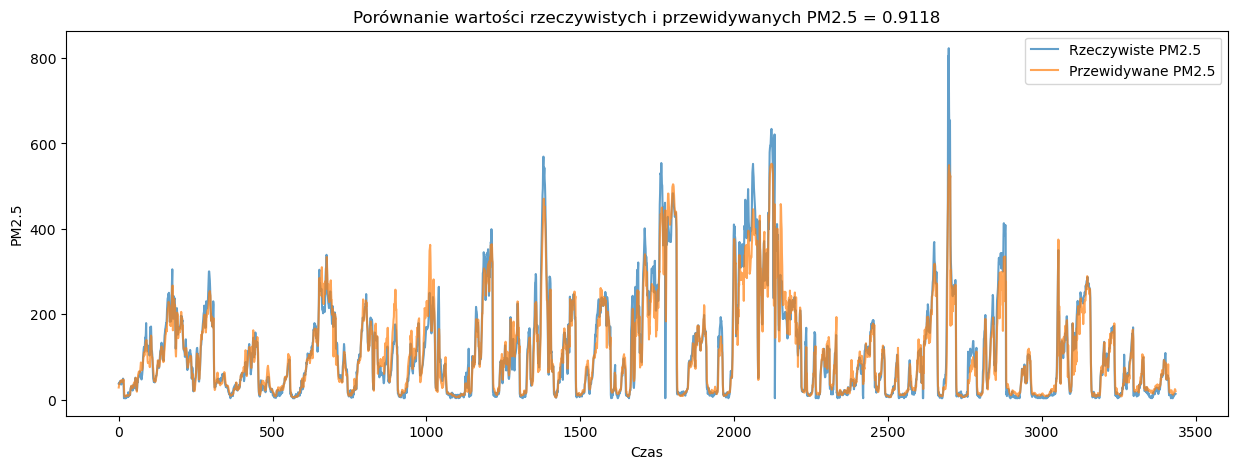

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Zbiór treningowy
y_train_pred_scaled = model.predict(X_train)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_train_true = scaler_y.inverse_transform(y_train)

# Zbiór testowy
y_test_pred_scaled = model.predict(X_test)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_true = scaler_y.inverse_transform(y_test)

# MSE i R²
mse_train = mean_squared_error(y_train_true, y_train_pred)
r2_train = r2_score(y_train_true, y_train_pred)

mse_test = mean_squared_error(y_test_true, y_test_pred)
r2_test = r2_score(y_test_true, y_test_pred)

print(f"Zbiór treningowy - MSE: {mse_train:.2f}, R²: {r2_train:.4f}")
print(f"Zbiór testowy    - MSE: {mse_test:.2f}, R²: {r2_test:.4f}")

plt.figure(figsize=(15, 5))
plt.plot(y_test_true, label='Rzeczywiste PM2.5', alpha=0.7)
plt.plot(y_test_pred, label='Przewidywane PM2.5', alpha=0.7)
plt.title(f'Porównanie wartości rzeczywistych i przewidywanych PM2.5 = {r2_test:.4f}')
plt.xlabel('Czas')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

In [35]:
#R2 powyżej 0.9 na zbiorze testowym — model wyjaśnia ponad 91% zmienności danych
#Na wykresie widać, że przewidywania dobrze nadążają za zmiennością danych.
#Różnice w MSE sugeruje, że nie doszło do silnego przeuczenia.

In [36]:
#11 Wnioski

In [42]:
#Jaka część wariancji zmiennej celu jest wyjaśniana przez model?
#Współczynnik R2 na zbiorze testowym wyniósł około 0.9118, co oznacza, że model jest w stanie wyjaśnić ponad 91% zmienności stężenia PM2.5.

#Wpływ uzupełniania braków danych przez interpolację vs. odrzucanie wierszy
#Zastosowanie interpolacji liniowej pozwoliło zachować pełną ciągłość szeregu czasowego oraz większą liczbę danych do treningu. 
#W przypadku odrzucania wierszy z brakami zauważalnie zmniejsza się liczebność próbek, co pogarsza jakość modelu oraz zwiększa ryzyko przeuczenia. 
#Interpolacja jest szczególnie uzasadniona przy danych o charakterze czasowym.

#Jaka wartość batch_size daje najszybsze tempo uczenia?
#W eksperymentach z wartościami 64, 128 oraz 256 zauważono, że:
    #Przy batch_size = 128 osiągnięto najlepszy kompromis między szybkością uczenia a stabilnością procesu,
    #Przy batch_size = 256 tempo uczenia było nieco wyższe, ale pogarszała się jakość przyrostów uczenia w każdej epoce,
    #Przy batch_size = 64 trenowanie było wolniejsze, ale możliwe do uzyskania nieco lepsze dopasowanie, kosztem wydłużonego czasu.
#Optymalna wartość dla tego zadania to 128, biorąc pod uwagę zarówno jakość modelu, jak i czas treningu.

#Tendencja modelu do przetrenowywania się oraz wpływ architektury i dropout
#Model wykazywał pewne oznaki przetrenowania po około 10–12 epokach, co było widoczne w rosnącej wartości funkcji straty.
#Dodanie trzech warstw dropout o wartości 0.2 skutecznie zredukowało to zjawisko. Zauważono także, że zwiększanie liczby komórek LSTM powyżej pewnego poziomu nie zawsze poprawiało wyniki.

#Wybór najlepszego algorytmu optymalizacyjnego
#Przeprowadzono porównanie trzech optymalizatorów: Adam, RMSprop i SGD. 
#Najlepszą stabilność i skuteczność wykazały optymalizatory Adam oraz RMSprop. 
#Adam uzyskał minimalnie lepszy współczynnik determinacji R² na zbiorze walidacyjnym i minimalnie niższą funkcję straty niż RMSprop. 
#Optymalizator SGD wypadł najsłabiej.

#Czy uwzględnienie kierunku wiatru (kolumna wd) miałoby istotny wpływ?
#W projekcie pominięto zmienną wd z uwagi na jej kategoryczny charakter, który nie jest bezpośrednio zrozumiały dla sieci LSTM.
#Gdyby zamienić kierunek wiatru na reprezentację liczbową można przypuszczać, że miałoby to pozytywny wpływ, zwłaszcza w kontekście rozchodzenia się zanieczyszczeń.